# LLaMA Token-Generation Latency Benchmark — GPU (Colab)

This notebook runs all benchmark experiments on a Colab GPU runtime.

**Setup:**
1. Runtime → Change runtime type → **GPU** (T4 or A100 with Colab Pro)
2. Set your GitHub repo URL in the next cell
3. Run cells top-to-bottom
4. Download results at the end

In [1]:
REPO_URL = "https://github.com/akash-chowdary-kodali/Adv-Architecture-Research-Project.git"

!git clone {REPO_URL}
%cd Adv-Architecture-Research-Project
!ls -la

Cloning into 'Adv-Architecture-Research-Project'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 41 (delta 12), reused 41 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 39.95 KiB | 1.74 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/Adv-Architecture-Research-Project
total 60
drwxr-xr-x 6 root root  4096 Mar  4 02:46 .
drwxr-xr-x 1 root root  4096 Mar  4 02:46 ..
drwxr-xr-x 3 root root  4096 Mar  4 02:46 analysis
drwxr-xr-x 2 root root  4096 Mar  4 02:46 benchmarks
drwxr-xr-x 8 root root  4096 Mar  4 02:46 .git
-rw-r--r-- 1 root root   314 Mar  4 02:46 .gitignore
-rw-r--r-- 1 root root 10282 Mar  4 02:46 INSTRUCTIONS.md
-rw-r--r-- 1 root root 12833 Mar  4 02:46 PROJECT-PLAN.md
-rw-r--r-- 1 root root   302 Mar  4 02:46 requirements.txt
drwxr-xr-x 2 root root  4096 Mar  4 02:46 scripts


In [2]:
!nvidia-smi

!pip install llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu122

!pip install transformers accelerate
!pip install numpy pandas matplotlib seaborn scipy

import torch
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory // (1024**2)} MB")

Wed Mar  4 02:47:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!bash scripts/download_models.sh

!ls -lh models/*.gguf

=== Downloading LLaMA 3.2 GGUF models ===
Llama-3.2-1B-Instruct-Q4_K_M.gguf:  95% 768M/808M [00:04<00:00, 154MB/s]
  Done.
Llama-3.2-1B-Instruct-Q8_0.gguf:  66% 873M/1.32G [00:04<00:02, 176MB/s] 
  Done.
Llama-3.2-1B-Instruct-f16.gguf:  62% 1.54G/2.48G [00:07<00:04, 203MB/s] 
  Done.
Llama-3.2-3B-Instruct-Q4_K_M.gguf:  60% 1.21G/2.02G [00:06<00:04, 184MB/s] 
  Done.
Llama-3.2-3B-Instruct-Q8_0.gguf:  88% 3.02G/3.42G [00:11<00:01, 260MB/s] 
  Done.

All models ready.

=== Models in models/ ===
-rw-r--r-- 1 root root 2.4G Mar  4 02:48 models/Llama-3.2-1B-Instruct-f16.gguf
-rw-r--r-- 1 root root 771M Mar  4 02:47 models/Llama-3.2-1B-Instruct-Q4_K_M.gguf
-rw-r--r-- 1 root root 1.3G Mar  4 02:47 models/Llama-3.2-1B-Instruct-Q8_0.gguf
-rw-r--r-- 1 root root 1.9G Mar  4 02:48 models/Llama-3.2-3B-Instruct-Q4_K_M.gguf
-rw-r--r-- 1 root root 3.2G Mar  4 02:48 models/Llama-3.2-3B-Instruct-Q8_0.gguf
-rw-r--r-- 1 root root 2.4G Mar  4 02:48 models/Llama-3.2-1B-Instruct-f16.gguf
-rw-r--r-- 1 root roo

In [4]:
!python -m benchmarks.benchmark_harness \
    --model llama-3.2-1b-q4 \
    --prompt-length 128 \
    --trials 1 \
    --warmup 1 \
    --output-tokens 32 \
    --output smoke_test.csv

Platform info: {'os': 'Linux', 'os_version': '#1 SMP Mon Feb  2 12:27:57 UTC 2026', 'machine': 'x86_64', 'processor': 'x86_64', 'python_version': '3.12.12', 'cpu_count': '12', 'platform_type': 'cuda_gpu', 'accelerator': 'CUDA', 'gpu_name': 'NVIDIA A100-SXM4-80GB', 'gpu_memory_mb': '81152'}
Models: ['llama-3.2-1b-q4']
Prompt lengths: [128]

Benchmarking: LLaMA-3.2-1B-Q4_K_M
Platform: GPU-NVIDIA A100-SXM4-80GB
Prompt length: ~128 tokens
Output length: 32 tokens
Trials: 1 warmup + 1 measured
Loading model...
Model loaded.
Running 1 warm-up iterations...
  Warm-up 1/1 done
Running 1 measurement trials...
  Trial 1/1: TTFT=4.65ms, mean_token=4.78ms, e2e=157.76ms, tokens=32

--- Results (after IQR outlier filtering) ---
TTFT:      mean=4.65ms, std=0.00ms
Token:     mean=4.78ms, p95=4.78ms
E2E:       mean=157.76ms
Throughput: 209.08 tokens/sec
Results saved to /content/Adv-Architecture-Research-Project/data/raw/smoke_test.csv
Results saved to /content/Adv-Architecture-Research-Project/data/ra

In [5]:
!python -m benchmarks.benchmark_harness \
    --all-models \
    --trials 10

Platform info: {'os': 'Linux', 'os_version': '#1 SMP Mon Feb  2 12:27:57 UTC 2026', 'machine': 'x86_64', 'processor': 'x86_64', 'python_version': '3.12.12', 'cpu_count': '12', 'platform_type': 'cuda_gpu', 'accelerator': 'CUDA', 'gpu_name': 'NVIDIA A100-SXM4-80GB', 'gpu_memory_mb': '81152'}
Models: ['llama-3.2-1b-q4', 'llama-3.2-1b-q8', 'llama-3.2-1b-f16', 'llama-3.2-3b-q4', 'llama-3.2-3b-q8']
Prompt lengths: [128, 256, 512, 1024]

Benchmarking: LLaMA-3.2-1B-Q4_K_M
Platform: GPU-NVIDIA A100-SXM4-80GB
Prompt length: ~128 tokens
Output length: 128 tokens
Trials: 3 warmup + 10 measured
Loading model...
Model loaded.
Running 3 warm-up iterations...
  Warm-up 1/3 done
  Warm-up 2/3 done
  Warm-up 3/3 done
Running 10 measurement trials...
  Trial 1/10: TTFT=4.52ms, mean_token=4.64ms, e2e=598.89ms, tokens=128
  Trial 2/10: TTFT=4.21ms, mean_token=4.64ms, e2e=597.71ms, tokens=128
  Trial 3/10: TTFT=4.13ms, mean_token=4.64ms, e2e=598.21ms, tokens=128
  Trial 4/10: TTFT=4.13ms, mean_token=4.64ms,

In [6]:
from huggingface_hub import login
login()

!python -m benchmarks.latency_decomposition \
    --device cuda \
    --tokens 64

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Platform: {'os': 'Linux', 'os_version': '#1 SMP Mon Feb  2 12:27:57 UTC 2026', 'machine': 'x86_64', 'processor': 'x86_64', 'python_version': '3.12.12', 'cpu_count': '12', 'platform_type': 'cuda_gpu', 'accelerator': 'CUDA', 'gpu_name': 'NVIDIA A100-SXM4-80GB', 'gpu_memory_mb': '81152'}
Loading model: meta-llama/Llama-3.2-1B-Instruct
Device: cuda, Dtype: torch.float16
CRITICAL: Using attn_implementation='eager' for per-component timing
config.json: 100% 877/877 [00:00<00:00, 3.34MB/s]
tokenizer_config.json: 100% 54.5k/54.5k [00:00<00:00, 2.67MB/s]
tokenizer.json: 100% 9.09M/9.09M [00:01<00:00, 6.31MB/s]
special_tokens_map.json: 100% 296/296 [00:00<00:00, 1.47MB/s]
`torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors:  60% 1.48G/2.47G [00:07<00:04, 202MB/s] 
Loading weights: 100% 146/146 [00:00<00:00, 182.95it/s, Materializing param=model.norm.weight]
generation_config.json: 100% 189/189 [00:00<00:00, 1.03MB/s]
Registered timing hooks on 67 components
Hooked components: ['e

In [7]:
!python -m benchmarks.scaling_analysis \
    --experiment all \
    --trials 5

Platform: {'os': 'Linux', 'os_version': '#1 SMP Mon Feb  2 12:27:57 UTC 2026', 'machine': 'x86_64', 'processor': 'x86_64', 'python_version': '3.12.12', 'cpu_count': '12', 'platform_type': 'cuda_gpu', 'accelerator': 'CUDA', 'gpu_name': 'NVIDIA A100-SXM4-80GB', 'gpu_memory_mb': '81152'}

############################################################
# EXPERIMENT 1: Sequence Length Scaling
# Model: LLaMA-3.2-1B-Q4_K_M
# Lengths: [128, 256, 512, 1024, 2048]
############################################################

Benchmarking: LLaMA-3.2-1B-Q4_K_M
Platform: GPU-NVIDIA A100-SXM4-80GB
Prompt length: ~128 tokens
Output length: 128 tokens
Trials: 3 warmup + 5 measured
Loading model...
Model loaded.
Running 3 warm-up iterations...
  Warm-up 1/3 done
  Warm-up 2/3 done
  Warm-up 3/3 done
Running 5 measurement trials...
  Trial 1/5: TTFT=4.67ms, mean_token=4.65ms, e2e=600.22ms, tokens=128
  Trial 2/5: TTFT=4.25ms, mean_token=4.66ms, e2e=600.51ms, tokens=128
  Trial 3/5: TTFT=4.15ms, mean_token=

In [8]:
!python -m analysis.bottleneck_analysis --model 1B --quant Q4_K_M

ARCHITECTURAL BOTTLENECK ANALYSIS
Model: LLaMA-3.2-1B | Sequence Length: 512 | Quantization: Q4_K_M

--- Arithmetic Intensity Analysis (Decode Step) ---
Component                        FLOPs        Bytes   AI (F/B)            Classification
-------------------------------------------------------------------------------------
attention_per_layer           25214976      6291456       4.01              memory-bound
attention_total              403439616    100663296       4.01              memory-bound
mlp_per_layer                100679680     25165824       4.00              memory-bound
mlp_total                   1610874880    402653184       4.00              memory-bound
lm_head                      525336576    131334144       4.00              memory-bound
total_decode_step           2539651072    634650624       4.00              memory-bound

--- KV-Cache Analysis ---
KV-cache size at seq_len=512: 16.00 MB
KV-cache size at seq_len=2048: 64.00 MB

Typical cache hierarchy sizes:


Using: scaling_gpu_A100-SXM4-80GB_20260304_025318_sequence_length.csv
Saved: scaling_sequence_length_gpu_A100-SXM4-80GB_20260304_025441.png
Using: scaling_gpu_A100-SXM4-80GB_20260304_025318_model_size.csv
Saved: scaling_model_size_gpu_A100-SXM4-80GB_20260304_025441.png
Using: scaling_gpu_A100-SXM4-80GB_20260304_025318_quantization.csv
Saved: scaling_quantization_gpu_A100-SXM4-80GB_20260304_025441.png
Using: decomposition_gpu_A100-SXM4-80GB_20260304_025239.json
Saved: decomposition_breakdown_gpu_A100-SXM4-80GB_20260304_025441.png
Using: benchmark_gpu_A100-SXM4-80GB_20260304_024845.json
Saved: token_timeline_llama-3.2-1b-q4_gpu_A100-SXM4-80GB_20260304_025441.png
Saved: token_timeline_llama-3.2-1b-q4_gpu_A100-SXM4-80GB_20260304_025441.png
Saved: token_timeline_llama-3.2-1b-q4_gpu_A100-SXM4-80GB_20260304_025441.png
Saved: token_timeline_llama-3.2-1b-q4_gpu_A100-SXM4-80GB_20260304_025441.png
Saved: token_timeline_llama-3.2-1b-q8_gpu_A100-SXM4-80GB_20260304_025441.png
Saved: token_timeline_l

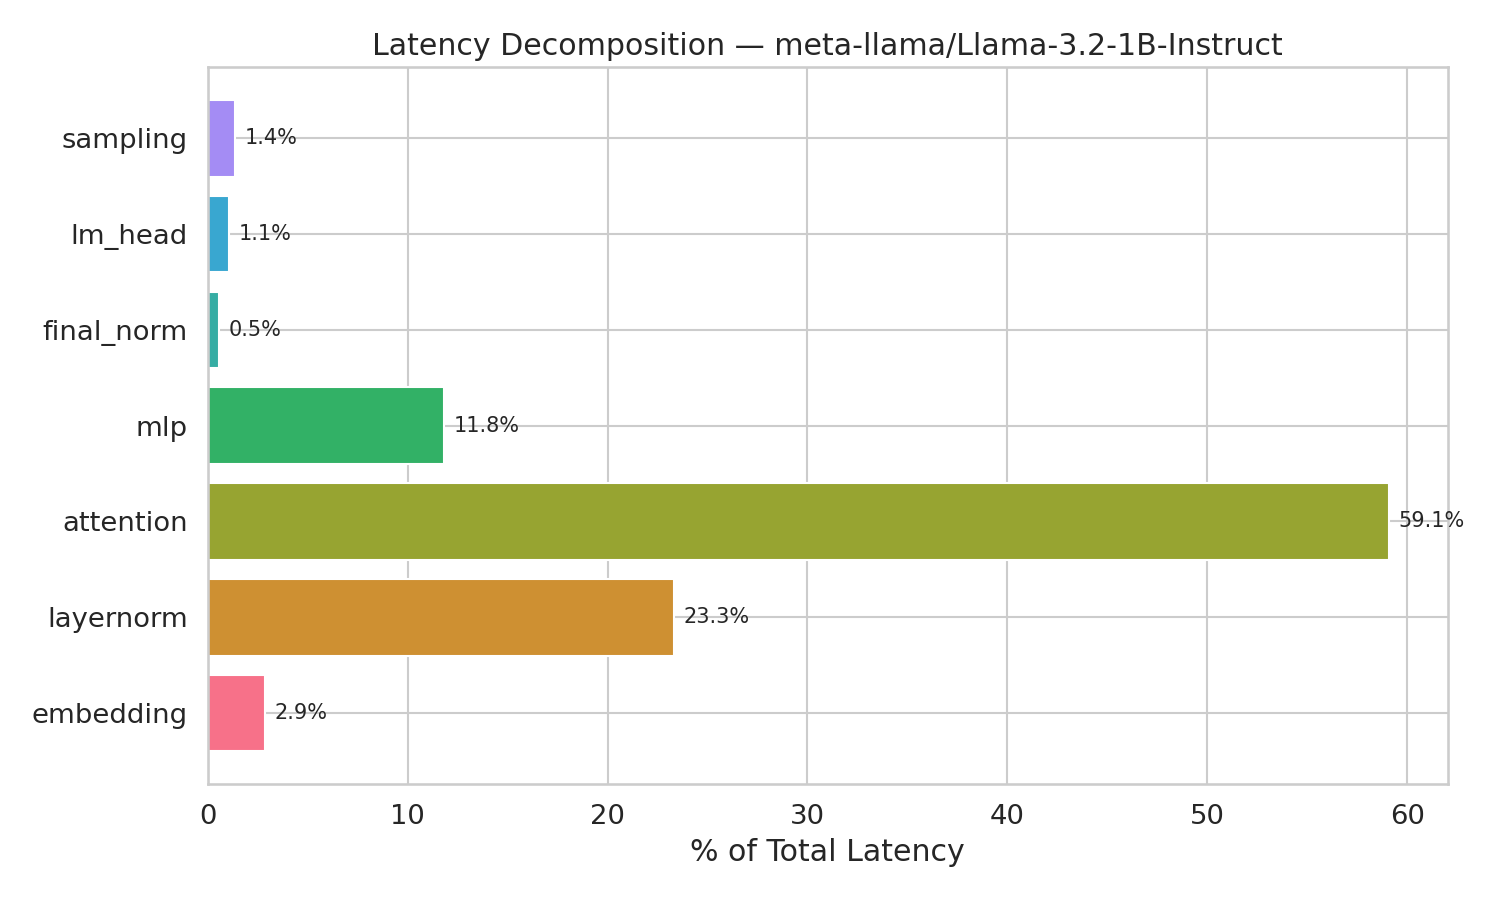


--- scaling_model_size_gpu_A100-SXM4-80GB_20260304_025441.png ---


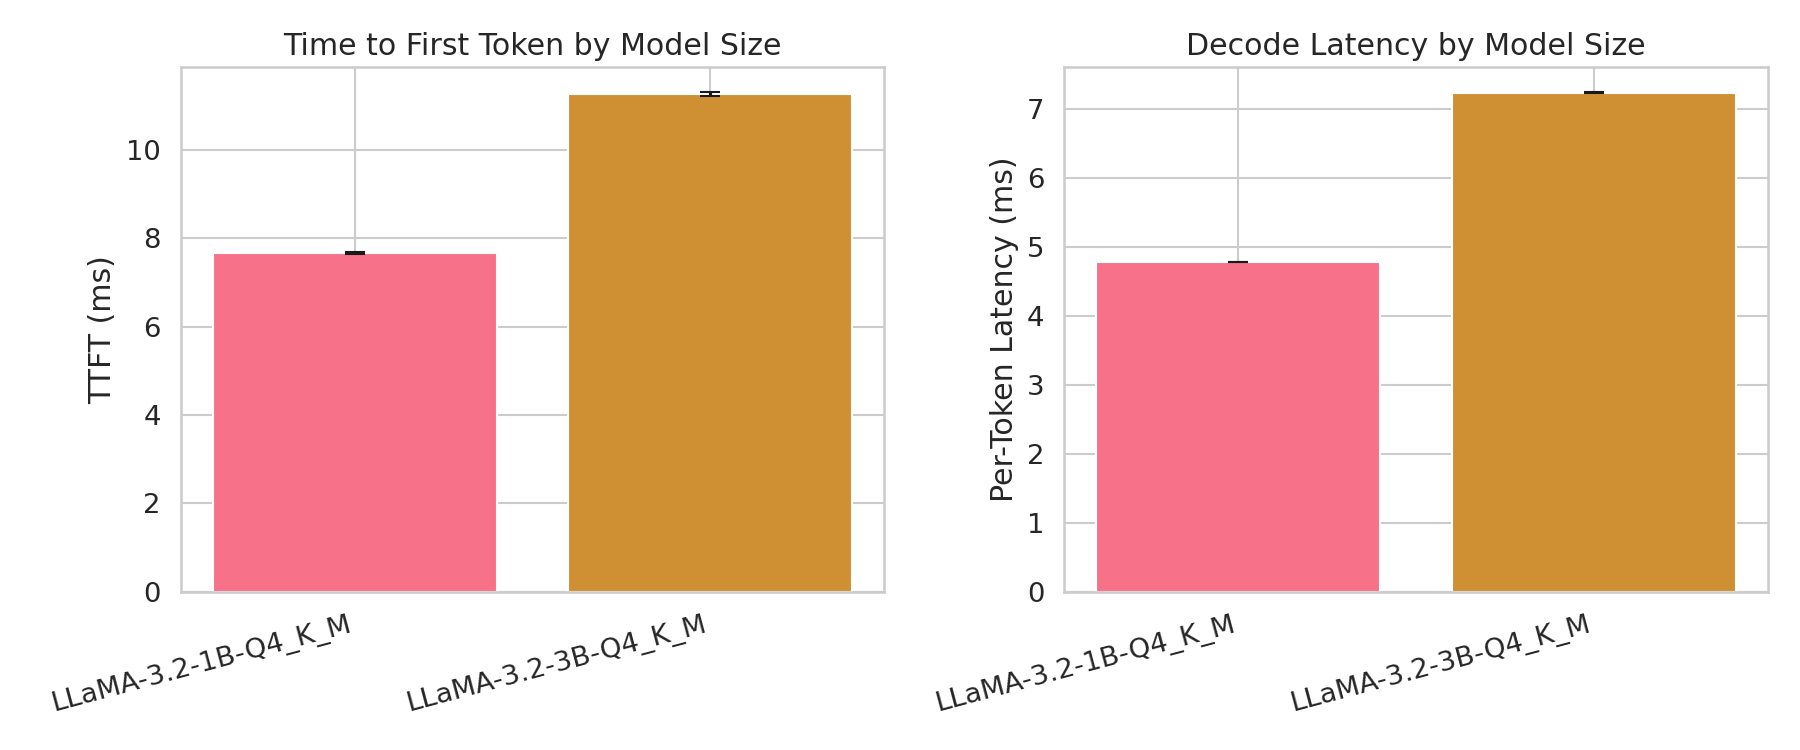


--- scaling_quantization_gpu_A100-SXM4-80GB_20260304_025441.png ---


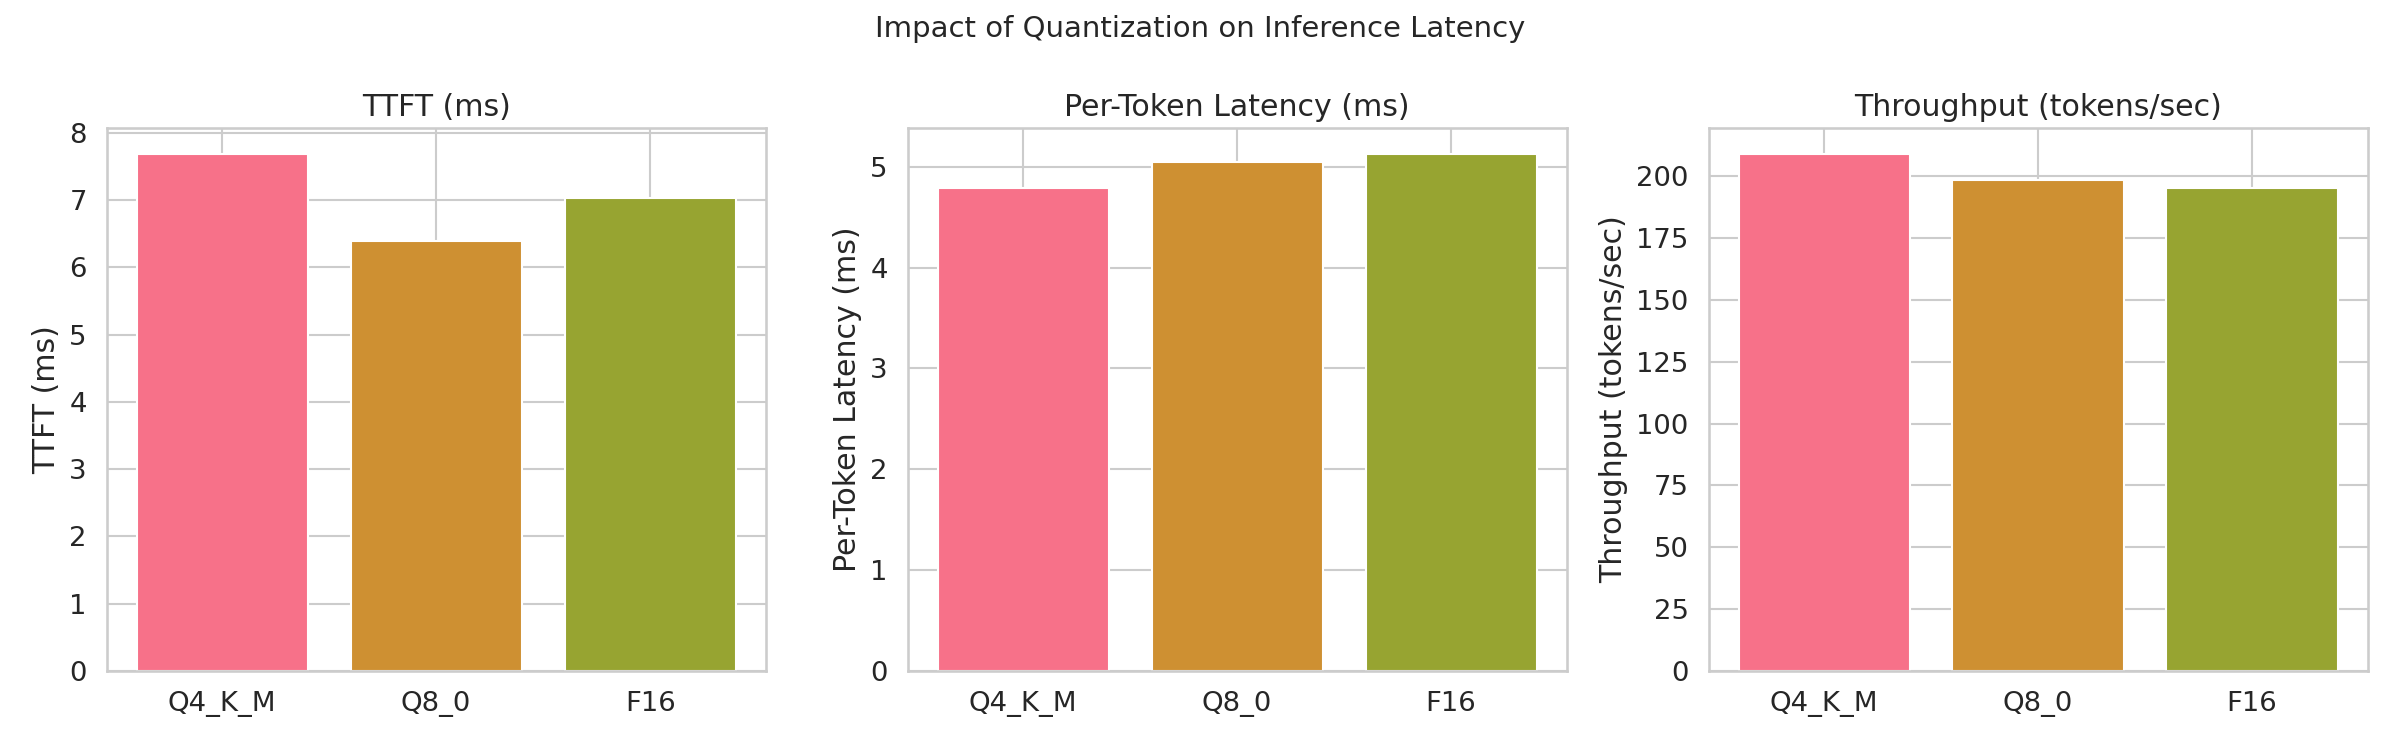


--- scaling_sequence_length_gpu_A100-SXM4-80GB_20260304_025441.png ---


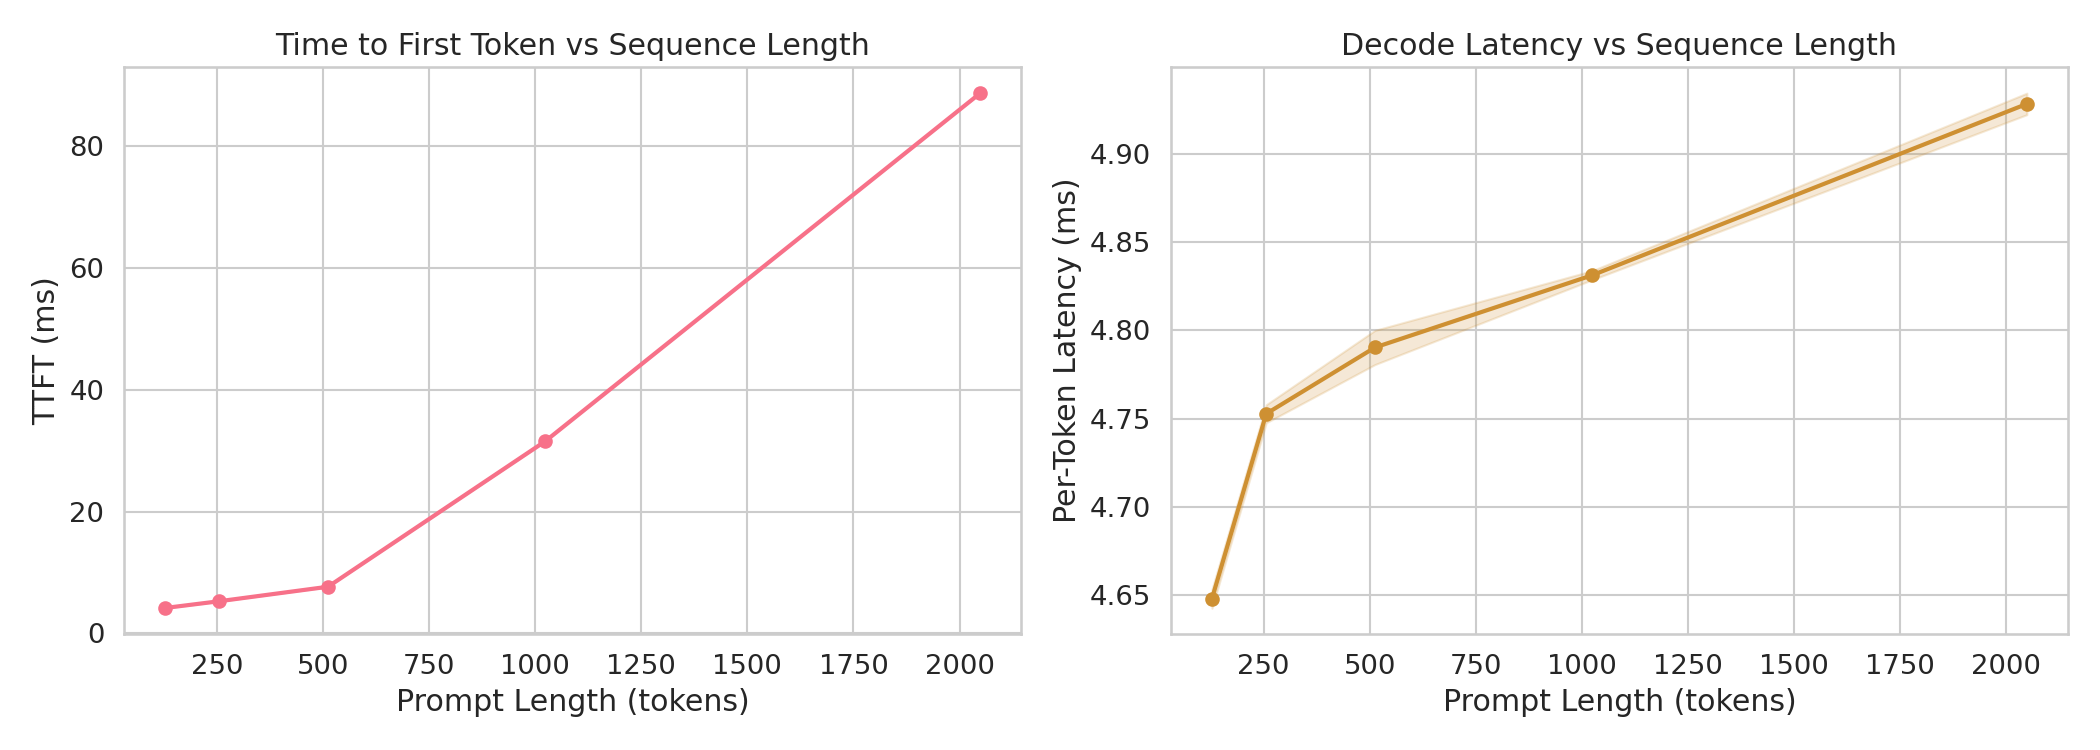


--- token_timeline_llama-3.2-1b-f16_gpu_A100-SXM4-80GB_20260304_025441.png ---


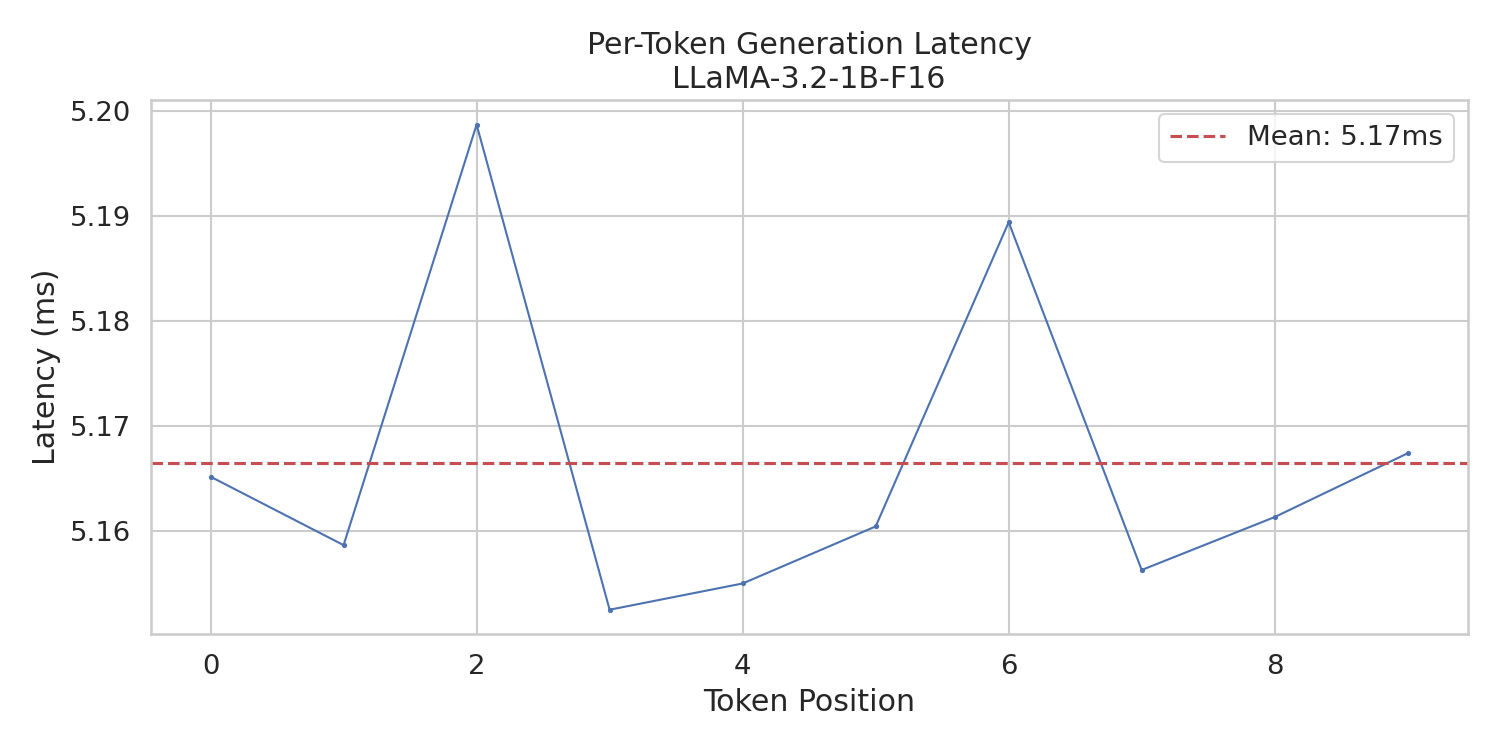


--- token_timeline_llama-3.2-1b-q4_gpu_A100-SXM4-80GB_20260304_025441.png ---


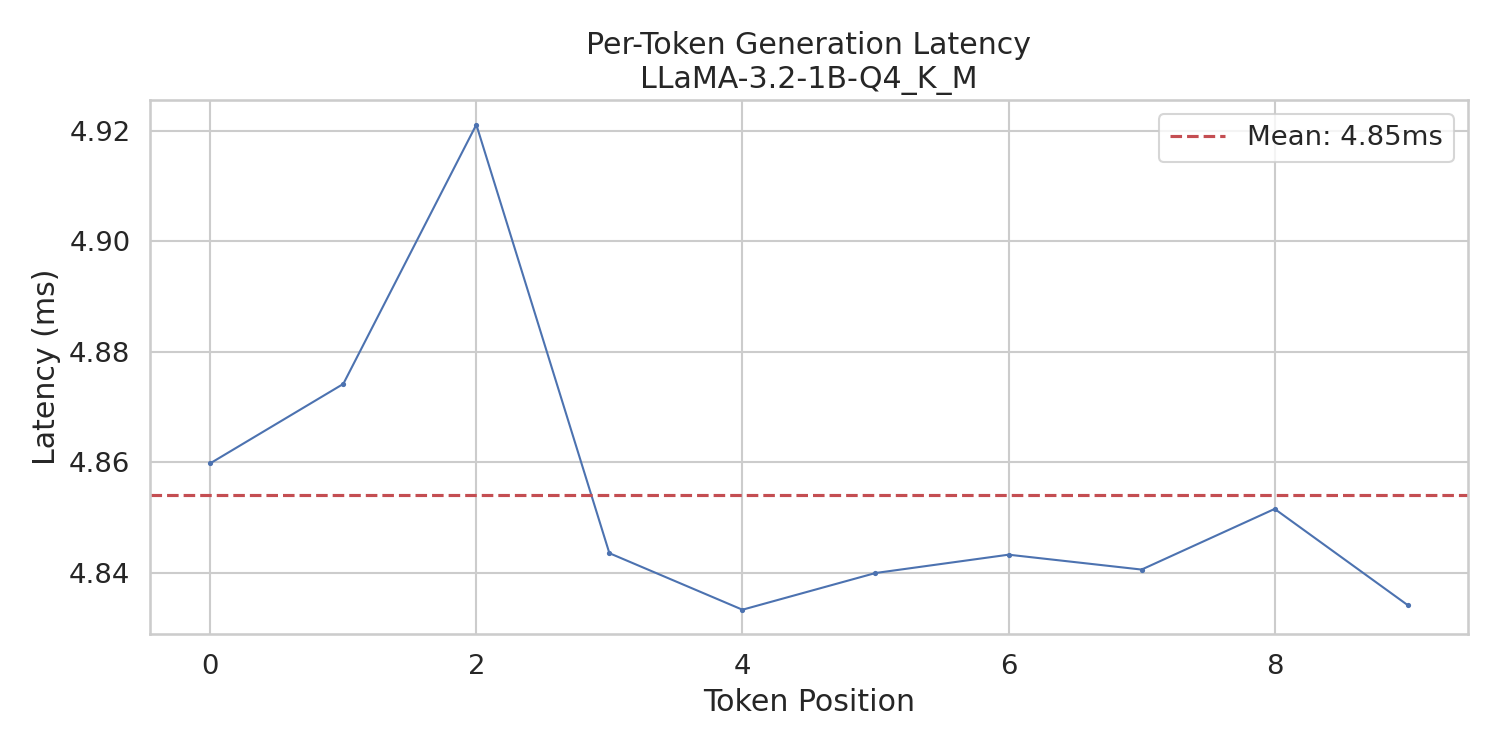


--- token_timeline_llama-3.2-1b-q8_gpu_A100-SXM4-80GB_20260304_025441.png ---


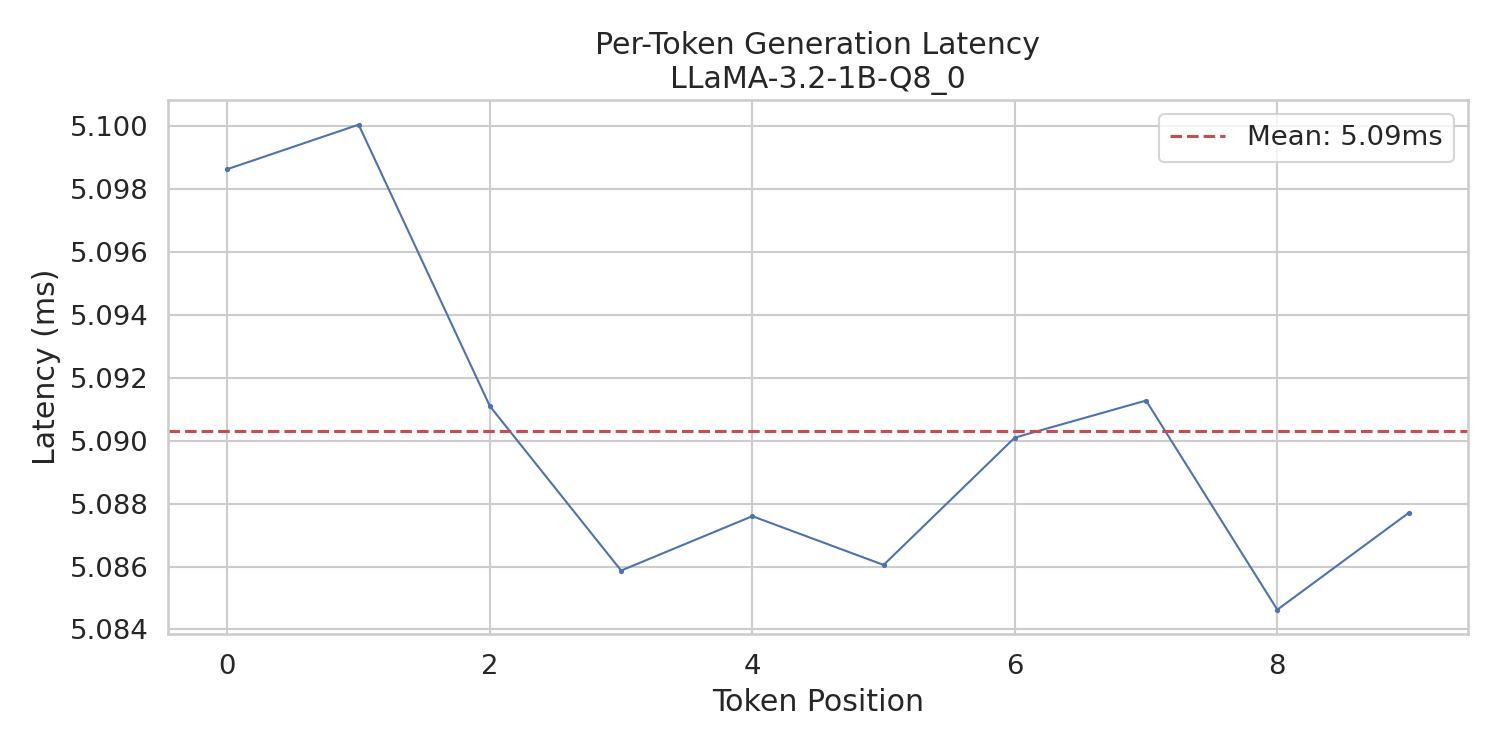


--- token_timeline_llama-3.2-3b-q4_gpu_A100-SXM4-80GB_20260304_025441.png ---


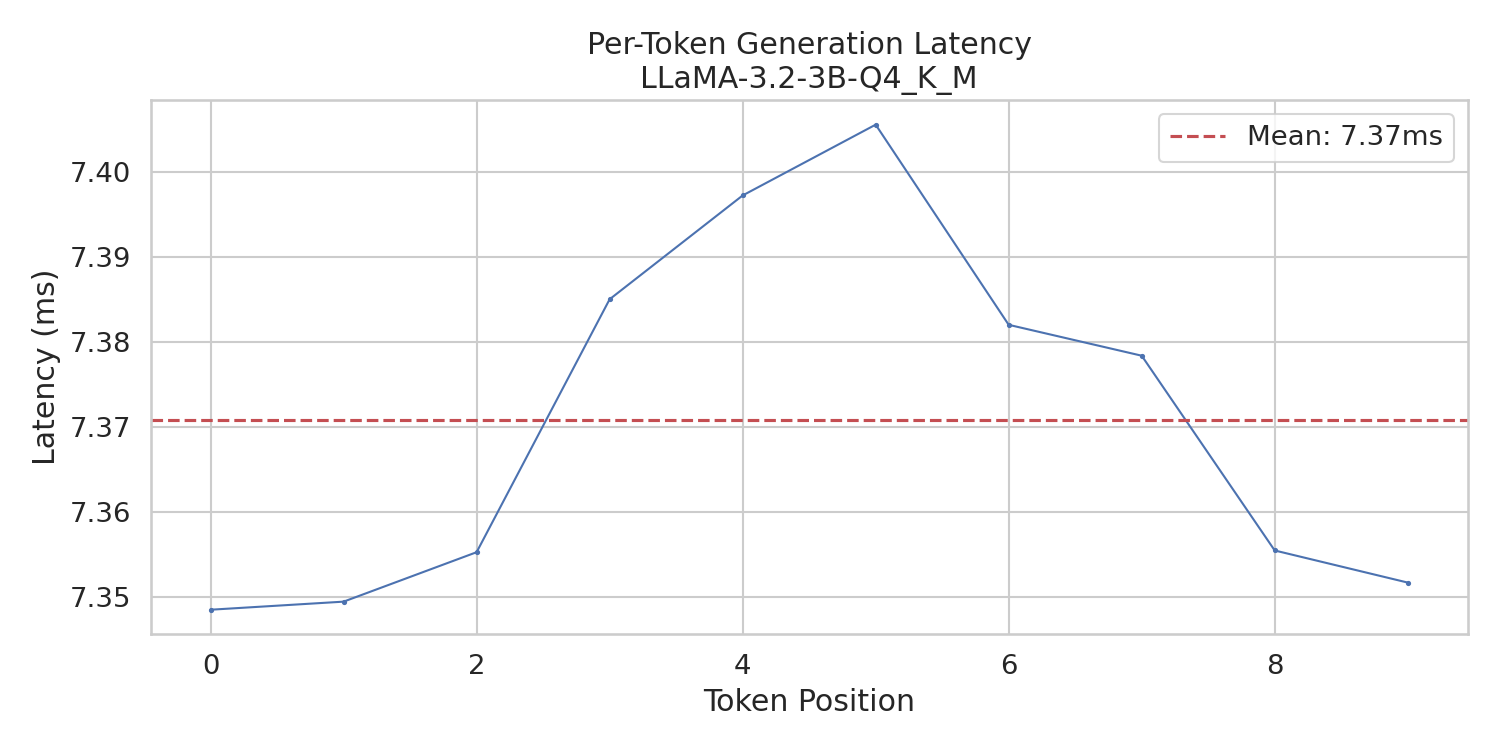


--- token_timeline_llama-3.2-3b-q8_gpu_A100-SXM4-80GB_20260304_025441.png ---


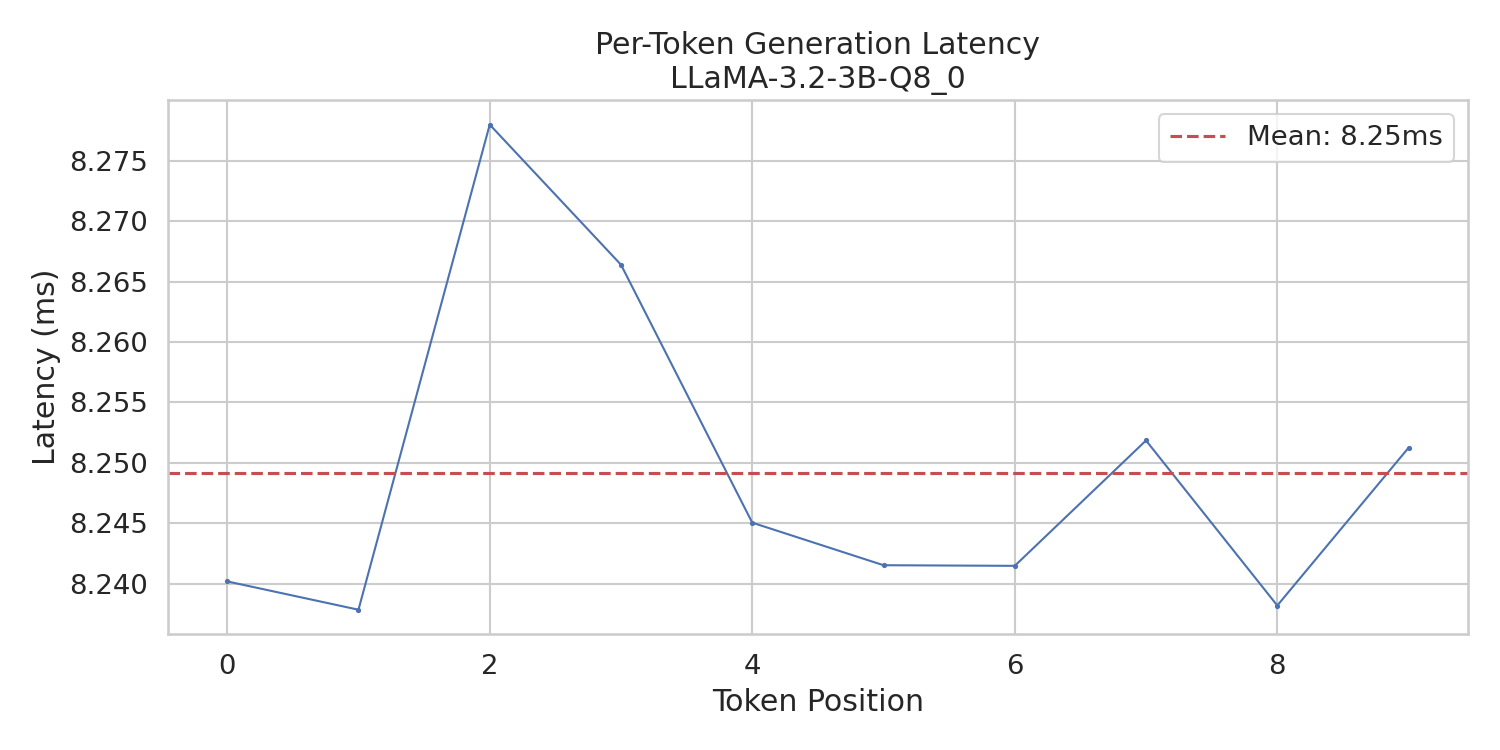

In [9]:
!python -m analysis.plot_results

import os
import glob
from IPython.display import Image, display

for img_path in sorted(glob.glob('results/*.png')):
    print(f"\n--- {os.path.basename(img_path)} ---")
    display(Image(filename=img_path, width=800))

In [11]:
import shutil
import os

shutil.make_archive('gpu_benchmark_results', 'zip', '.', 'data')
shutil.make_archive('gpu_benchmark_plots', 'zip', '.', 'results')

print("Raw data files:")
for f in sorted(glob.glob('data/raw/*')):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f} ({size_kb:.1f} KB)")

print("\nPlot files:")
for f in sorted(glob.glob('results/*.png')):
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f} ({size_kb:.1f} KB)")

try:
    from google.colab import files
    files.download('gpu_benchmark_results.zip')
    files.download('gpu_benchmark_plots.zip')
    print("\nDownload started!")
except ImportError:
    print("\nNot running in Colab browser — copy files manually from:")
    print(f"  {os.path.abspath('gpu_benchmark_results.zip')}")
    print(f"  {os.path.abspath('gpu_benchmark_plots.zip')}")

Raw data files:
  data/raw/benchmark_gpu_A100-SXM4-80GB_20260304_024845.csv (5.6 KB)
  data/raw/benchmark_gpu_A100-SXM4-80GB_20260304_024845.json (26.5 KB)
  data/raw/decomposition_gpu_A100-SXM4-80GB_20260304_025239.json (182.0 KB)
  data/raw/decomposition_gpu_A100-SXM4-80GB_20260304_025239_steps.csv (39.9 KB)
  data/raw/scaling_gpu_A100-SXM4-80GB_20260304_025318_all.json (11.8 KB)
  data/raw/scaling_gpu_A100-SXM4-80GB_20260304_025318_model_size.csv (0.8 KB)
  data/raw/scaling_gpu_A100-SXM4-80GB_20260304_025318_quantization.csv (1.1 KB)
  data/raw/scaling_gpu_A100-SXM4-80GB_20260304_025318_sequence_length.csv (1.7 KB)
  data/raw/smoke_test.csv (0.5 KB)
  data/raw/smoke_test.json (0.8 KB)

Plot files:
  results/decomposition_breakdown_gpu_A100-SXM4-80GB_20260304_025441.png (63.5 KB)
  results/scaling_model_size_gpu_A100-SXM4-80GB_20260304_025441.png (63.4 KB)
  results/scaling_quantization_gpu_A100-SXM4-80GB_20260304_025441.png (80.2 KB)
  results/scaling_sequence_length_gpu_A100-SXM4-8

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started!
